# Exploratory Data Analysis (EDA)

## Objectives

- Understand sales performance
- Identify revenue leakage
- Discover customer purchasing behavior
- Analyze country-wise performance
- Find trends over time

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [38]:
# Load the cleaned dataset

file_path = "../data/cleaned/online_retail_cleaned.csv"

df = pd.read_csv(file_path)

In [39]:
# Convert InvoiceDate back to datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset loaded successfully.")
print(f"Dataset Shape: {df.shape}")

Dataset loaded successfully.
Dataset Shape: (515665, 14)


In [40]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Invoice Year,Invoice Month,Year-Month,Invoice Day,Invoice Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,2009-12,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,2009-12,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,2009-12,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,2009-12,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,2009-12,1,7


## Total Revenue

**Business Question:** How much revenue did the company generate after cleaning?


In [41]:
# Calculate total revenue

total_revenue = df["Revenue"].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £9,642,327.58


### Key Insight

**£9.64M total revenue** after cleaning. This is the baseline for the analysis.


## Total Orders

**Business Question:** How many unique orders were placed after cleaning?


In [42]:
# Calculate total unique orders

total_orders = df["Invoice"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 25,885


## Key Insight

**25,885 unique orders** were recorded.


## Total Customers

**Business Question:** How many unique customers made purchases?


In [43]:
# Calculate total unique customers

total_customers = df["Customer ID"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 4,383


## Key Insight

**4,383 customers** placed orders during the analysis period.


## Average Order Value (AOV)

**Business Question:** What is the average revenue per order?


In [44]:
# Calculate Average Order Value

average_order_value = total_revenue / total_orders

print(f"Average Order Value: £{average_order_value:,.2f}")

Average Order Value: £372.51


## Key Insight

**AOV: £372.51** per order.


# Revenue by Year

**Business Question:** How did total revenue change across years?


In [45]:
# Calculate yearly revenue

yearly_revenue = (
    df.groupby("Invoice Year")["Revenue"]
      .sum()
      .reset_index()
)

yearly_revenue

,Invoice Year,Revenue
0,2009,796648.500
1,2010,8845679.084


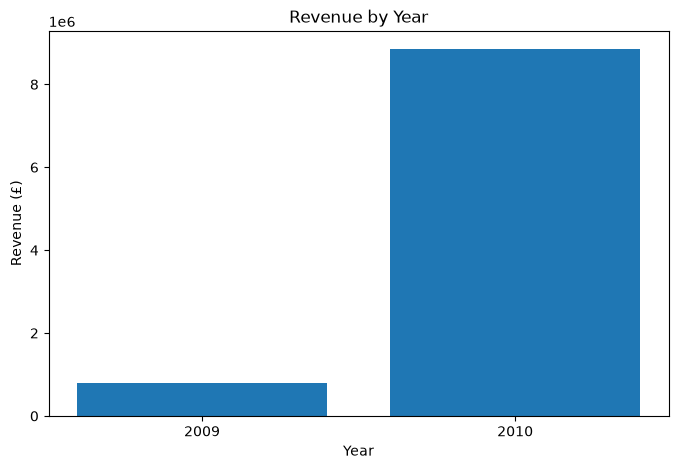

In [46]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_revenue["Invoice Year"].astype(str),
    yearly_revenue["Revenue"]
)

plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue (£)")

plt.show()

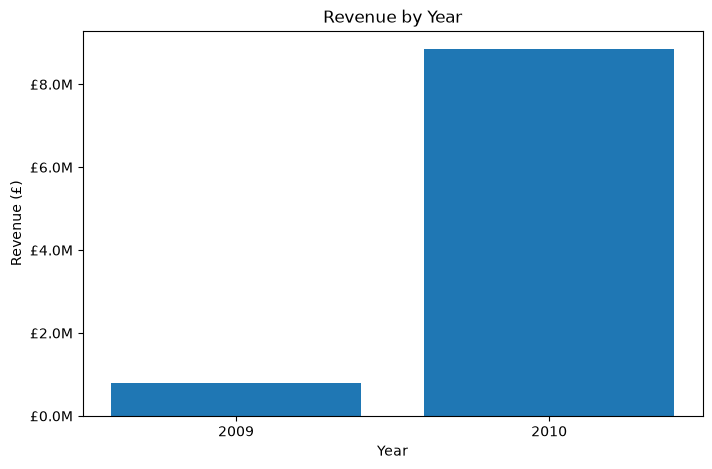

In [47]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8,5))

plt.bar(
    yearly_revenue["Invoice Year"].astype(str),
    yearly_revenue["Revenue"]
)

plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue (£)")

# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1e6:.1f}M")
)

plt.show()

## Key Insight

Revenue was **£796.6K in 2009** and **£8.85M in 2010**. The comparison is directional because 2009 contains only December.


# Revenue by Month

**Business Question:** How did revenue change across months?


In [48]:
# Calculate monthly revenue

monthly_revenue = (
    df.groupby("Year-Month")["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue.head()

,Year-Month,Revenue
0,2009-12,796648.500
1,2010-01,622479.502
2,2010-02,531265.366
3,2010-03,763247.241
4,2010-04,641521.052


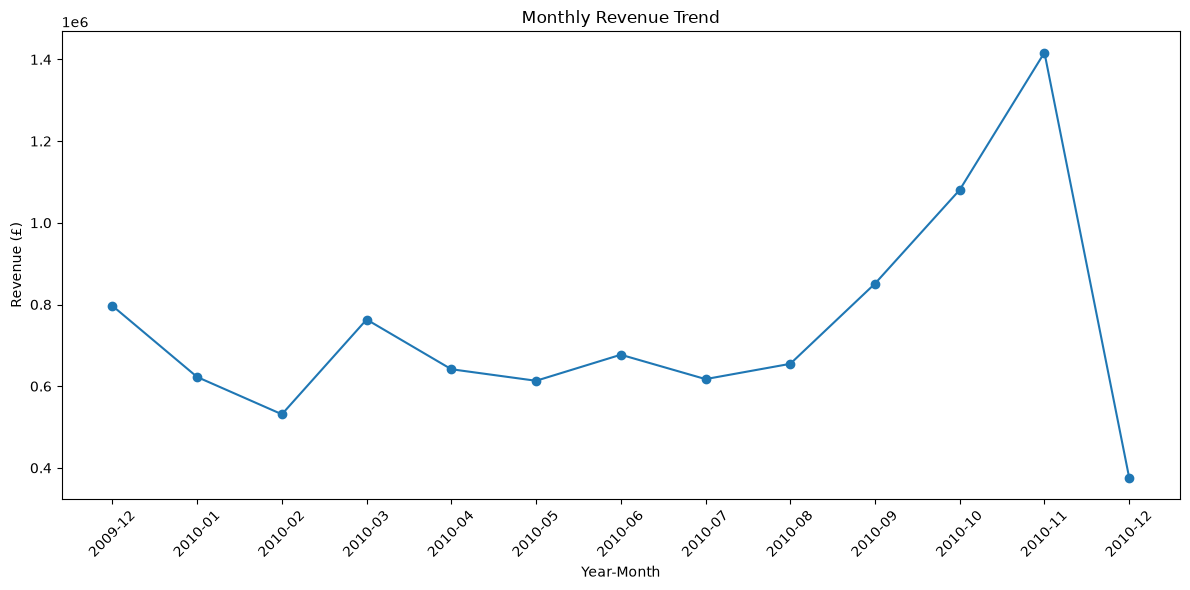

In [49]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["Year-Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

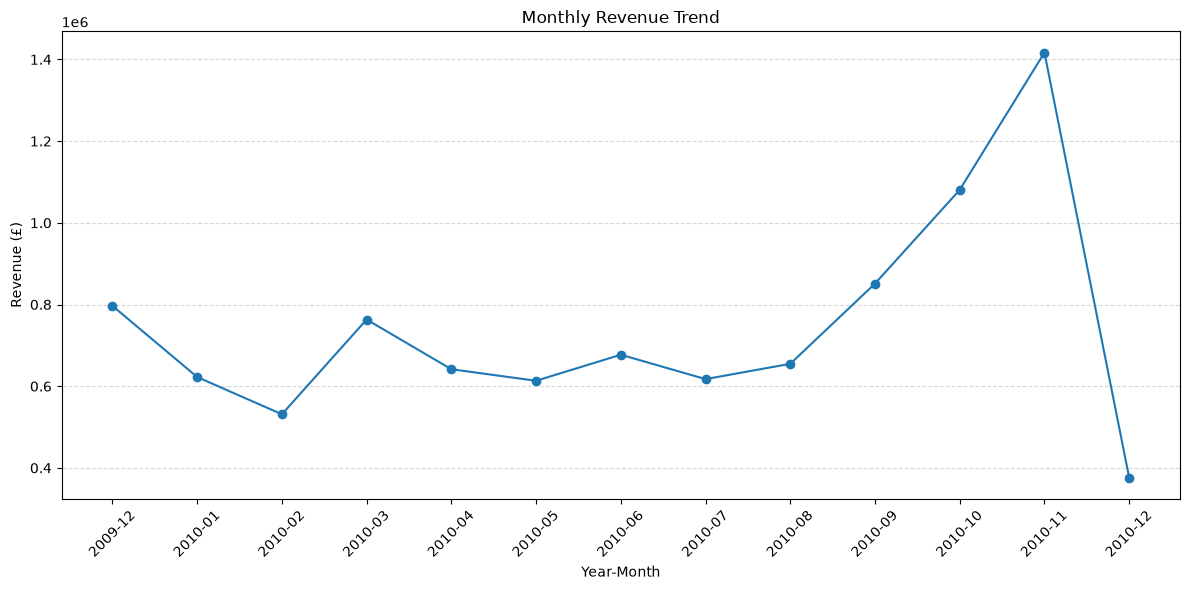

In [50]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["Year-Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

## Key Insight

Revenue peaked in **November 2010**. December is incomplete, so its decline should not be interpreted as a full-month drop.


# Revenue Leakage Analysis

**Business Question:** How much revenue is lost through returned or cancelled orders?


In [51]:
# Identify returned transactions

returns = df[df["Invoice"].astype(str).str.startswith("C")]

print(f"Returned Transactions: {len(returns):,}")

Returned Transactions: 10,182


In [52]:
# Revenue lost due to returns

revenue_lost = returns["Revenue"].sum()

print(f"Revenue Lost: £{abs(revenue_lost):,.2f}")

Revenue Lost: £629,435.08


In [53]:
# Percentage of revenue lost

revenue_leakage_pct = (
    abs(revenue_lost) / total_revenue
) * 100

print(f"Revenue Leakage: {revenue_leakage_pct:.2f}%")

Revenue Leakage: 6.53%


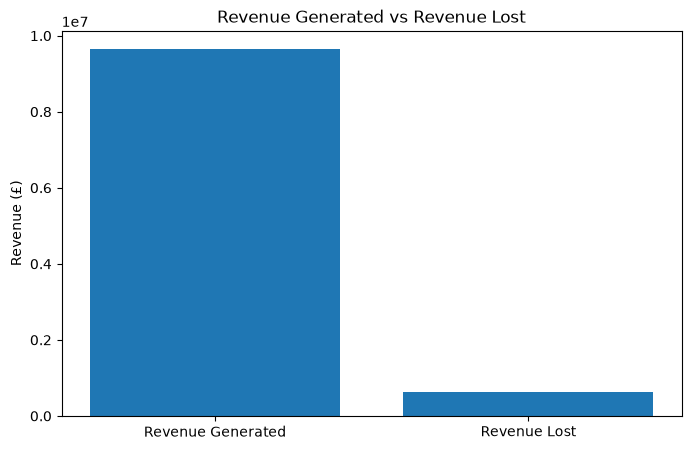

In [54]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Revenue Generated", "Revenue Lost"],
    [total_revenue, abs(revenue_lost)]
)

plt.title("Revenue Generated vs Revenue Lost")
plt.ylabel("Revenue (£)")

plt.show()

## Key Insight

**10,182 returned transactions** created approximately **£629.4K leakage**, equal to **6.53% of revenue**.


## Revenue Leakage Summary

In [55]:
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Revenue Lost",
        "Revenue Leakage",
        "Returned Transactions"
    ],
    "Value": [
        f"£{total_revenue:,.2f}",
        f"£{abs(revenue_lost):,.2f}",
        f"{revenue_leakage_pct:.2f}%",
        f"{len(returns):,}"
    ]
})

summary

,Metric,Value
0,Total Revenue,"£9,642,327.58"
1,Revenue Lost,"£629,435.08"
2,Revenue Leakage,6.53%
3,Returned Transactions,"10,182"


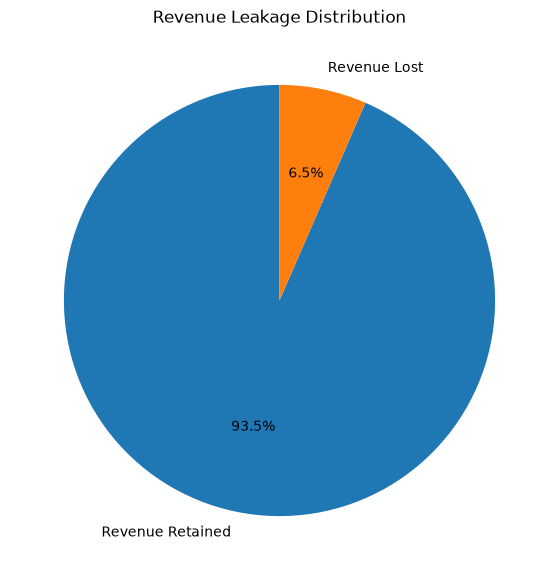

In [56]:
plt.figure(figsize=(7,7))

plt.pie(
    [total_revenue - abs(revenue_lost), abs(revenue_lost)],
    labels=["Revenue Retained", "Revenue Lost"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Leakage Distribution")

plt.show()

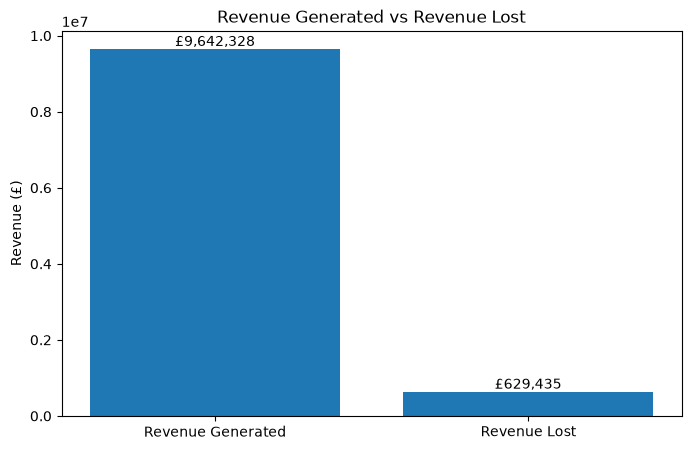

In [57]:
values = [total_revenue, abs(revenue_lost)]
labels = ["Revenue Generated", "Revenue Lost"]

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values)

plt.title("Revenue Generated vs Revenue Lost")
plt.ylabel("Revenue (£)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"£{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

## Key Insight

Returns represent a material leakage point. The next focus is **where the leakage comes from: countries, products, and customers**.


# Revenue Leakage by Country

**Business Question:** Which countries contribute most to revenue leakage?


In [58]:
# Calculate revenue lost by country

country_leakage = (
    returns.groupby("Country")["Revenue"]
    .sum()
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)

country_leakage.head(10)

,Country,Revenue
0,United Kingdom,514067.05
1,EIRE,28673.89
2,Norway,19864.61
3,France,16441.59
4,Spain,10516.52
5,Germany,6104.97
6,Netherlands,4922.59
7,Hong Kong,4280.26
8,Denmark,3933.90
9,Channel Islands,3179.00


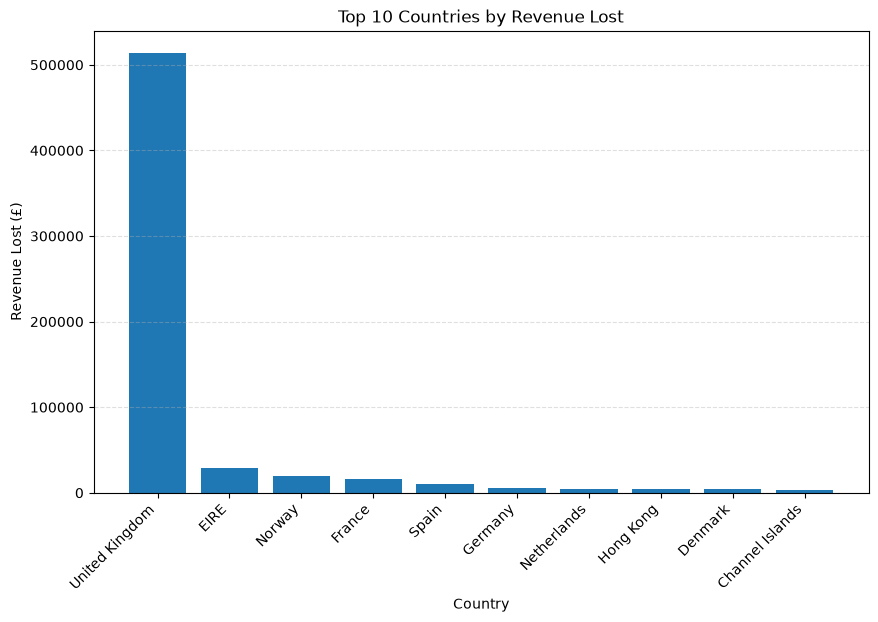

In [59]:
top10_country_leakage = country_leakage.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10_country_leakage["Country"],
    top10_country_leakage["Revenue"]
)

plt.title("Top 10 Countries by Revenue Lost")
plt.xlabel("Country")
plt.ylabel("Revenue Lost (£)")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

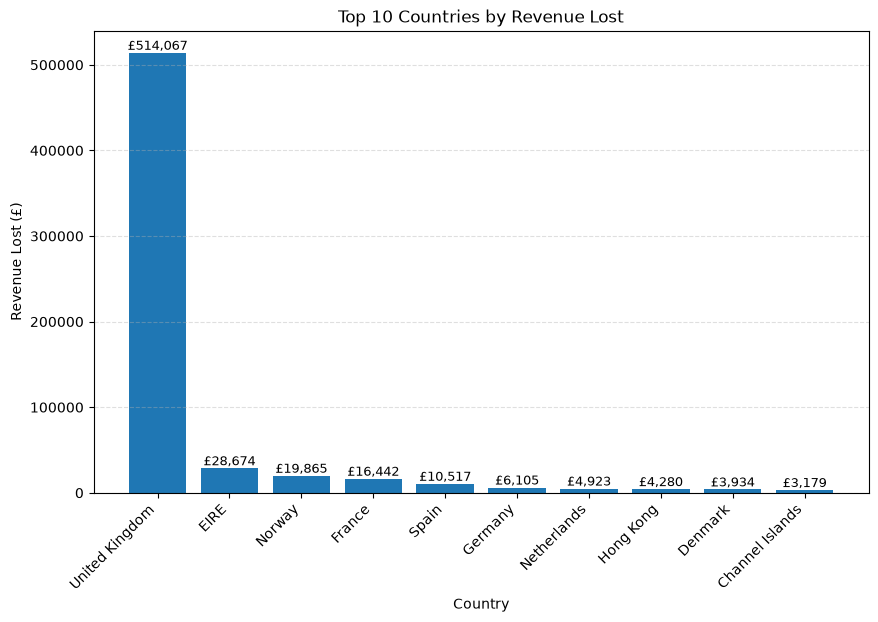

In [60]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    top10_country_leakage["Country"],
    top10_country_leakage["Revenue"]
)

plt.title("Top 10 Countries by Revenue Lost")
plt.xlabel("Country")
plt.ylabel("Revenue Lost (£)")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"£{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

## Key Insight

The **UK accounts for ~£514.1K** of lost revenue. Because the UK also dominates sales, country-level **return rate** should be used alongside absolute leakage.


In [61]:
# Revenue lost by product

product_leakage = (
    returns.groupby("Description")["Revenue"]
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

product_leakage

Description
Manual                               276715.20
AMAZON FEE                            59491.12
Bank Charges                          26657.27
Discount                               8186.21
REGENCY CAKESTAND 3 TIER               7027.05
WHITE CHERRY LIGHTS                    6277.30
PINK CHERRY LIGHTS                     3967.35
SET/4 WHITE RETRO STORAGE CUBES        3939.40
BAKING SET 9 PIECE RETROSPOT           3761.65
COLOUR GLASS. STAR T-LIGHT HOLDER      3730.25
Name: Revenue, dtype: float64

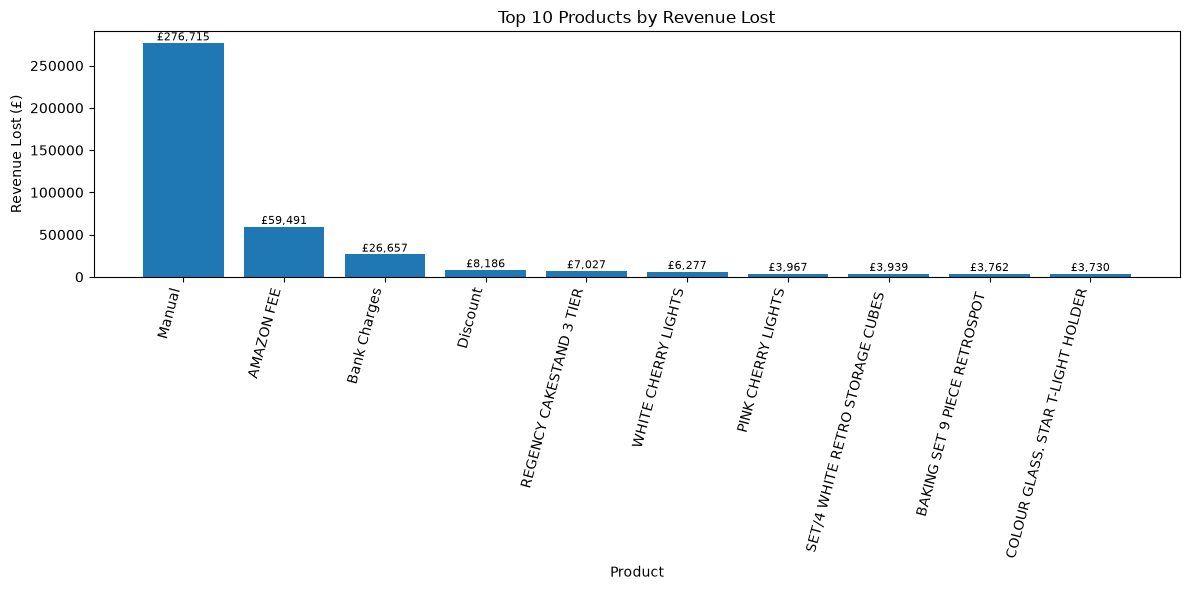

In [62]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    product_leakage.index,
    product_leakage.values
)

plt.title("Top 10 Products by Revenue Lost")
plt.xlabel("Product")
plt.ylabel("Revenue Lost (£)")
plt.xticks(rotation=75, ha="right")

# Add labels

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"£{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [63]:
exclude = [
    "Manual",
    "AMAZON FEE",
    "Bank Charges",
    "Discount"
]

product_returns = returns[
    ~returns["Description"].isin(exclude)
]

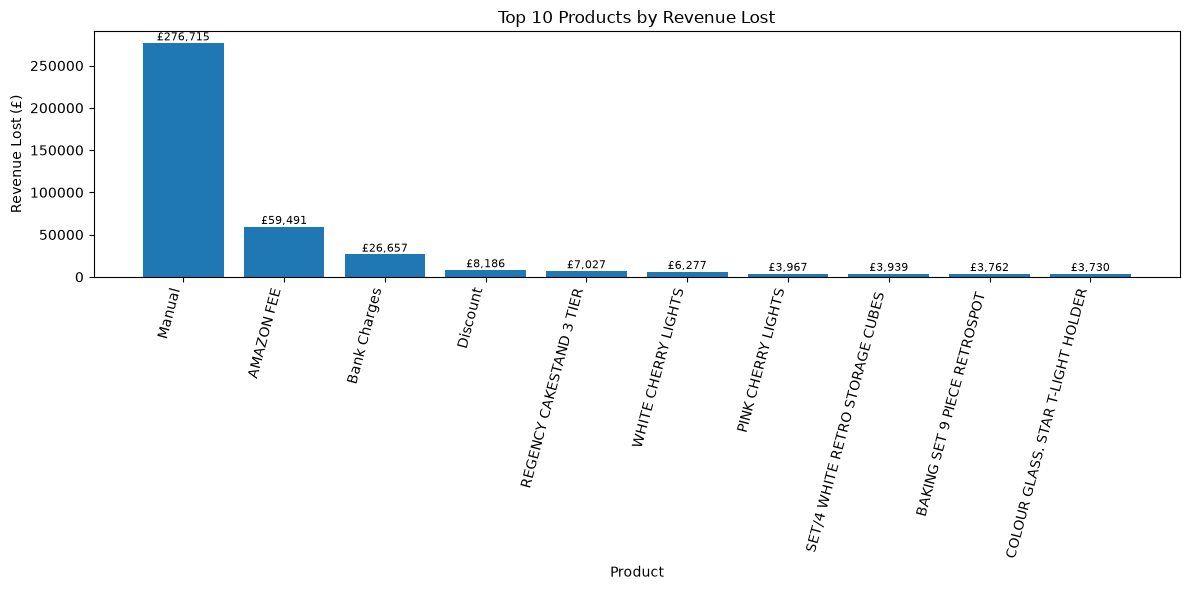

In [64]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    product_leakage.index,
    product_leakage.values
)

plt.title("Top 10 Products by Revenue Lost")
plt.xlabel("Product")
plt.ylabel("Revenue Lost (£)")
plt.xticks(rotation=75, ha="right")

# Add labels

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"£{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [65]:
# Remove operational/accounting records

exclude = [
    "Manual",
    "AMAZON FEE",
    "Bank Charges",
    "Discount"
]

product_returns = returns[
    ~returns["Description"].isin(exclude)
]

In [66]:
# Top 10 retail products by revenue lost

product_leakage_clean = (
    product_returns
    .groupby("Description")["Revenue"]
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

product_leakage_clean

Description
REGENCY CAKESTAND 3 TIER              7027.05
WHITE CHERRY LIGHTS                   6277.30
PINK CHERRY LIGHTS                    3967.35
SET/4 WHITE RETRO STORAGE CUBES       3939.40
BAKING SET 9 PIECE RETROSPOT          3761.65
COLOUR GLASS. STAR T-LIGHT HOLDER     3730.25
SMALL FAIRY CAKE FRIDGE MAGNETS       3645.65
POSTAGE                               3385.18
SAMPLES                               3090.21
WHITE HANGING HEART T-LIGHT HOLDER    2765.35
Name: Revenue, dtype: float64

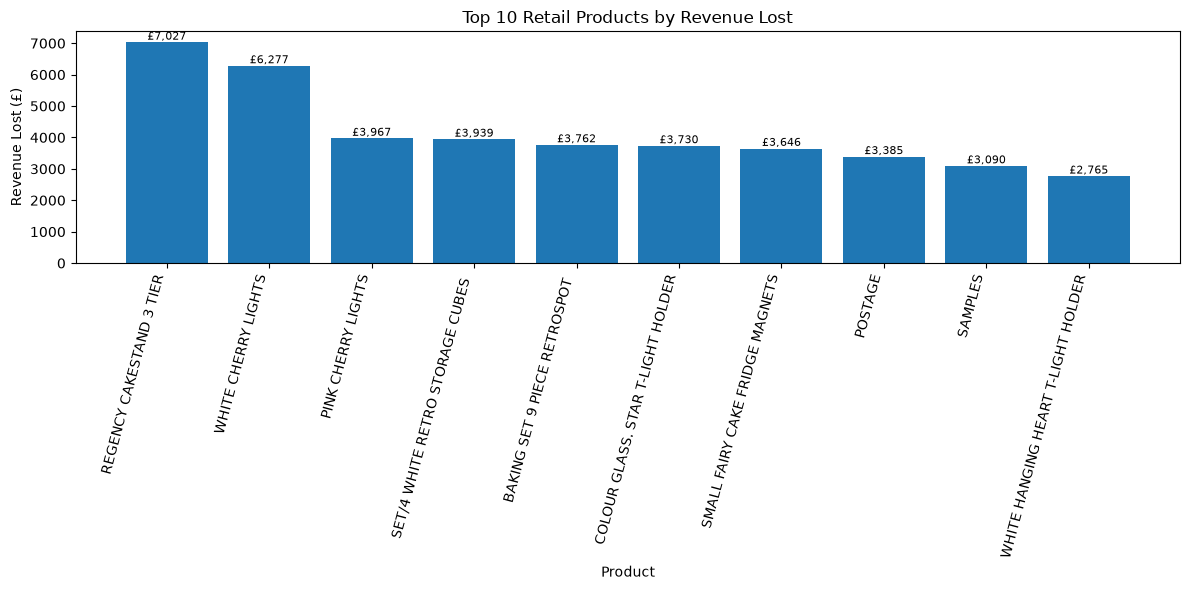

In [67]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    product_leakage_clean.index,
    product_leakage_clean.values
)

plt.title("Top 10 Retail Products by Revenue Lost")
plt.xlabel("Product")
plt.ylabel("Revenue Lost (£)")

plt.xticks(rotation=75, ha="right")

# Add value labels

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"£{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

## Key Insight

Top product leakage came from **REGENCY CAKESTAND 3 TIER (£7.03K)**, **WHITE CHERRY LIGHTS (£6.28K)**, and **PINK CHERRY LIGHTS (£3.97K)**.


## Top 10 Customers by Revenue Lost

**Business Question:** Which customers generated the highest revenue loss through returned purchases?


In [68]:
# Revenue lost by customer

customer_leakage = (
    returns.groupby("Customer ID")["Revenue"]
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

customer_leakage

Customer ID
14063.0    26477.40
17399.0    25111.09
12918.0    21907.00
15760.0    19712.21
14911.0    14410.46
17949.0    13972.85
14156.0    13386.19
14277.0    12642.14
12931.0    12454.52
16754.0    10941.89
Name: Revenue, dtype: float64

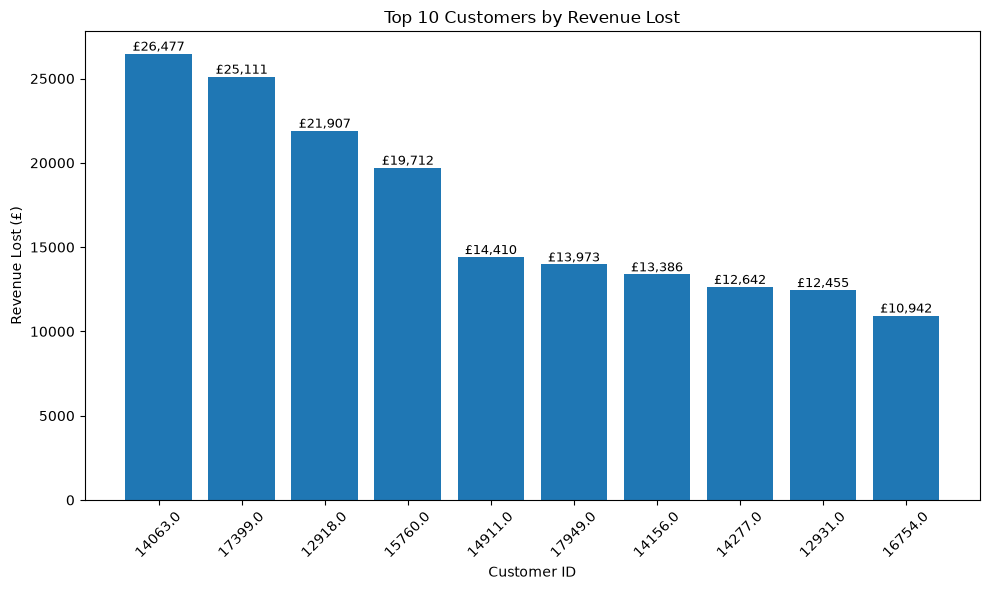

In [69]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    customer_leakage.index.astype(str),
    customer_leakage.values
)

plt.title("Top 10 Customers by Revenue Lost")
plt.xlabel("Customer ID")
plt.ylabel("Revenue Lost (£)")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"£{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Key Insight

Leakage is concentrated among a small group of customers. The highest-return customer generated approximately **£26.48K** in lost revenue.


## Revenue Leakage Trend Over Time

**Business Question:** How did returned revenue change over time?


In [70]:
# Monthly revenue leakage

monthly_leakage = (
    returns.groupby("Year-Month")["Revenue"]
    .sum()
    .abs()
    .reset_index()
)

monthly_leakage

,Year-Month,Revenue
0,2009-12,25835.45
1,2010-01,28675.61
2,2010-02,20239.36
3,2010-03,67668.02
4,2010-04,37354.20
5,2010-05,44434.78
6,2010-06,72463.44
7,2010-07,31444.79
8,2010-08,40477.52
9,2010-09,70591.03


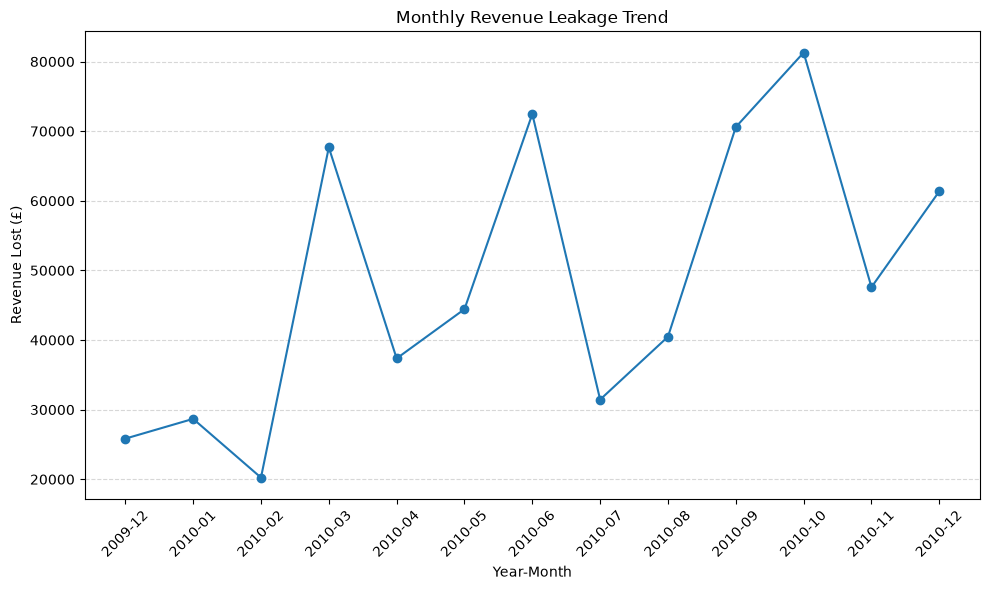

In [71]:
plt.figure(figsize=(10,6))

plt.plot(
    monthly_leakage["Year-Month"].astype(str),
    monthly_leakage["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Leakage Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue Lost (£)")
plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

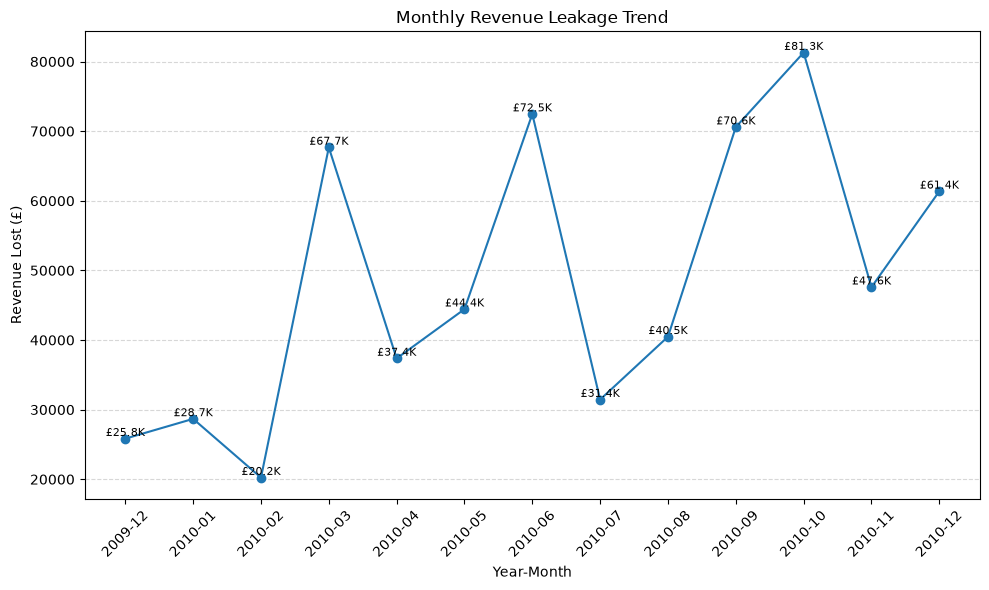

In [72]:
plt.figure(figsize=(10,6))

plt.plot(
    monthly_leakage["Year-Month"].astype(str),
    monthly_leakage["Revenue"],
    marker="o"
)

for x, y in zip(
    monthly_leakage["Year-Month"].astype(str),
    monthly_leakage["Revenue"]
):
    plt.text(
        x,
        y,
        f"£{y/1000:.1f}K",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.title("Monthly Revenue Leakage Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue Lost (£)")
plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Key Findings & Recommendations

- **Products:** Prioritize quality, packaging, and customer-feedback reviews for the highest-return products.
- **Countries:** Compare return rates, not just absolute leakage, to identify underperforming markets.
- **Customers:** Review high-return customers for recurring issues, fulfilment problems, or unusual behaviour.
- **Timing:** Investigate return spikes alongside promotions, inventory, shipping, and seasonality.
- **Dashboard:** Monitor revenue, returns, return rate, products, countries, and customers in Power BI.
